# Modèle Coulomb — prédiction d'énergie moléculaire

Ce notebook construit une baseline complète pour prédire l'énergie d'atomisation de petites molécules à partir de fichiers `.xyz`.

L'idée centrale est de représenter chaque molécule par une **matrice de Coulomb triée**, puis d'ajouter des features de preprocessing physiquement motivées : composition atomique, statistiques de distances, rayons covalents, électronégativités et liaisons approximatives.

Le notebook est organisé pour répondre directement aux critères du projet :

1. **Data preprocessing** : chargement, contrôles, statistiques, visualisations du dataset et visualisations 3D de molécules.
2. **Modèle** : matrice de Coulomb, discussion des invariances et enrichissement des features.
3. **Analyse / évaluation** : validation croisée, comparaison de modèles, tuning, plots train/validation, analyse des erreurs out-of-fold.
4. **Soumission Kaggle** : entraînement final et génération du fichier `id,energy`.
5. **Perspective** : limites, état de l'art et pistes d'amélioration.


## 1. Configuration et imports

On centralise les chemins et les paramètres importants au début du notebook. Cela rend le notebook plus facile à modifier si l'organisation du projet change.


In [1]:
from pathlib import Path
from collections import Counter
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    go = None
    PLOTLY_AVAILABLE = False

try:
    import py3Dmol
    PY3DMOL_AVAILABLE = True
except ImportError:
    py3Dmol = None
    PY3DMOL_AVAILABLE = False

try:
    from ase.io import read as ase_read
    from ase import Atoms
    from ase.neighborlist import NeighborList, natural_cutoffs
    ASE_AVAILABLE = True
except ImportError:
    ase_read = None
    Atoms = None
    NeighborList = None
    natural_cutoffs = None
    ASE_AVAILABLE = False

from sklearn.model_selection import KFold, cross_validate, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5

print("Plotly disponible :", PLOTLY_AVAILABLE)
print("py3Dmol disponible:", PY3DMOL_AVAILABLE)
print("ASE disponible    :", ASE_AVAILABLE)


Plotly disponible : True
py3Dmol disponible: True
ASE disponible    : True


In [2]:
# Le notebook peut être exécuté depuis Projet/Model_Coulomb ou depuis la racine Projet.
CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "data" / "atoms").exists():
    PROJECT_DIR = CURRENT_DIR
    NOTEBOOK_DIR = PROJECT_DIR / "Model_Coulomb"
else:
    NOTEBOOK_DIR = CURRENT_DIR
    PROJECT_DIR = NOTEBOOK_DIR.parent

TRAIN_ATOMS_DIR = PROJECT_DIR / "data" / "atoms" / "train"
TEST_ATOMS_DIR = PROJECT_DIR / "data" / "atoms" / "test"
ENERGY_PATH = PROJECT_DIR / "data" / "energies" / "train.csv"

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


def save_current_figure(name: str) -> None:
    """Sauvegarde la figure matplotlib courante pour le rapport."""
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Figure sauvegardée: {path}")

print("PROJECT_DIR     :", PROJECT_DIR)
print("NOTEBOOK_DIR    :", NOTEBOOK_DIR)
print("TRAIN_ATOMS_DIR :", TRAIN_ATOMS_DIR, TRAIN_ATOMS_DIR.exists())
print("TEST_ATOMS_DIR  :", TEST_ATOMS_DIR, TEST_ATOMS_DIR.exists())
print("ENERGY_PATH     :", ENERGY_PATH, ENERGY_PATH.exists())
print("OUTPUT_DIR      :", OUTPUT_DIR)
print("FIGURES_DIR     :", FIGURES_DIR)


PROJECT_DIR     : /Users/victorlin/Desktop/N7 3A/Projet
NOTEBOOK_DIR    : /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb
TRAIN_ATOMS_DIR : /Users/victorlin/Desktop/N7 3A/Projet/data/atoms/train True
TEST_ATOMS_DIR  : /Users/victorlin/Desktop/N7 3A/Projet/data/atoms/test True
ENERGY_PATH     : /Users/victorlin/Desktop/N7 3A/Projet/data/energies/train.csv True
OUTPUT_DIR      : /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs
FIGURES_DIR     : /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures


## 2. Chargement des données

On charge d'abord les énergies connues du train, puis les fichiers `.xyz`.  
Les IDs des fichiers doivent correspondre aux IDs présents dans `train.csv`.


In [3]:
energy_df = pd.read_csv(ENERGY_PATH)
energy_df = energy_df.sort_values("id").reset_index(drop=True)

display(energy_df.head())
print("Shape:", energy_df.shape)
print("Colonnes:", list(energy_df.columns))
print("Valeurs manquantes:")
print(energy_df.isna().sum())
print("\nStatistiques énergie:")
display(energy_df["energy"].describe())


,id,energy
0,1,-68.402811
1,2,-74.500691
2,3,-82.496414
3,4,-68.552768
4,5,-69.688330


Shape: (3306, 2)
Colonnes: ['id', 'energy']
Valeurs manquantes:
id        0
energy    0
dtype: int64

Statistiques énergie:


count    3306.000000
mean      -70.578505
std        10.317695
min      -103.413076
25%       -75.750647
50%       -69.422278
75%       -63.777722
max       -19.313757
Name: energy, dtype: float64

In [4]:
def extract_id_from_path(path: Path) -> int:
    """Extrait l'identifiant entier d'un fichier de type id_123.xyz."""
    return int(path.stem.split("_")[1])

train_files = sorted(TRAIN_ATOMS_DIR.glob("id_*.xyz"), key=extract_id_from_path)
test_files = sorted(TEST_ATOMS_DIR.glob("id_*.xyz"), key=extract_id_from_path)

print("Nombre fichiers train:", len(train_files))
print("Nombre fichiers test :", len(test_files))
print("Nombre total         :", len(train_files) + len(test_files))

train_ids_from_files = [extract_id_from_path(path) for path in train_files]
assert set(train_ids_from_files) == set(energy_df["id"]), "Mismatch entre train.csv et fichiers .xyz train"


Nombre fichiers train: 3306
Nombre fichiers test : 826
Nombre total         : 4132


## 3. Lecture des molécules `.xyz`

Chaque molécule est stockée sous forme de dictionnaire avec :

- son `id` ;
- ses symboles chimiques ;
- ses numéros atomiques ;
- ses coordonnées 3D ;
- son nombre d'atomes.


In [5]:
def parse_xyz_manually(xyz_path: Path) -> tuple[list[str], np.ndarray, np.ndarray]:
    """Lit un fichier .xyz simple sans dépendance externe."""
    raw_lines = xyz_path.read_text().splitlines()
    n_atoms = int(raw_lines[0].strip())
    atom_lines = raw_lines[2:2 + n_atoms]

    symbols = []
    positions = []
    for line in atom_lines:
        parts = line.split()
        symbols.append(parts[0])
        positions.append([float(parts[1]), float(parts[2]), float(parts[3])])

    atomic_number_map = {
        "H": 1,
        "C": 6,
        "N": 7,
        "O": 8,
        "F": 9,
        "S": 16,
        "Cl": 17,
    }
    atomic_numbers = np.array([atomic_number_map[symbol] for symbol in symbols], dtype=int)
    return symbols, atomic_numbers, np.asarray(positions, dtype=float)


def load_molecule(xyz_path: Path) -> dict:
    """
    Lit un fichier .xyz et retourne une structure Python simple.

    ASE est utilisé si disponible. Sinon, on utilise un parseur manuel adapté au format du projet.
    """
    if ASE_AVAILABLE:
        atoms = ase_read(xyz_path)
        symbols = atoms.get_chemical_symbols()
        atomic_numbers = np.asarray(atoms.get_atomic_numbers(), dtype=int)
        positions = np.asarray(atoms.get_positions(), dtype=float)
    else:
        symbols, atomic_numbers, positions = parse_xyz_manually(xyz_path)

    return {
        "id": extract_id_from_path(xyz_path),
        "symbols": symbols,
        "atomic_numbers": atomic_numbers,
        "positions": positions,
        "n_atoms": len(symbols),
        "path": xyz_path,
    }

all_train_molecules = [load_molecule(path) for path in train_files]
all_test_molecules = [load_molecule(path) for path in test_files]

train_molecules_by_id = {mol["id"]: mol for mol in all_train_molecules}
test_molecules_by_id = {mol["id"]: mol for mol in all_test_molecules}

test_ids = sorted(test_molecules_by_id.keys())

example = all_train_molecules[0]
print("Exemple molécule:")
print("ID:", example["id"])
print("Nombre d'atomes:", example["n_atoms"])
print("Symboles:", example["symbols"])
print("Numéros atomiques:", example["atomic_numbers"])
print("Positions shape:", example["positions"].shape)


Exemple molécule:
ID: 1
Nombre d'atomes: 14
Symboles: ['C', 'C', 'C', 'C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
Numéros atomiques: [6 6 6 6 6 8 1 1 1 1 1 1 1 1]
Positions shape: (14, 3)


## 4. Exploration rapide

Cette partie vérifie la distribution des tailles de molécules et la composition chimique.  
C'est utile pour comprendre quelles features d'enrichissement peuvent être pertinentes.


In [6]:
train_n_atoms = np.array([mol["n_atoms"] for mol in all_train_molecules])
test_n_atoms = np.array([mol["n_atoms"] for mol in all_test_molecules])

MAX_ATOMS = int(max(train_n_atoms.max(), test_n_atoms.max()))

print("Nombre maximal d'atomes:", MAX_ATOMS)
print("Taille moyenne train:", train_n_atoms.mean())
print("Taille moyenne test :", test_n_atoms.mean())
print("Taille min/max train:", train_n_atoms.min(), train_n_atoms.max())
print("Taille min/max test :", test_n_atoms.min(), test_n_atoms.max())


Nombre maximal d'atomes: 23
Taille moyenne train: 15.247428917120388
Taille moyenne test : 15.24818401937046
Taille min/max train: 5 23
Taille min/max test : 4 23


Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/distribution_taille_molecules.png


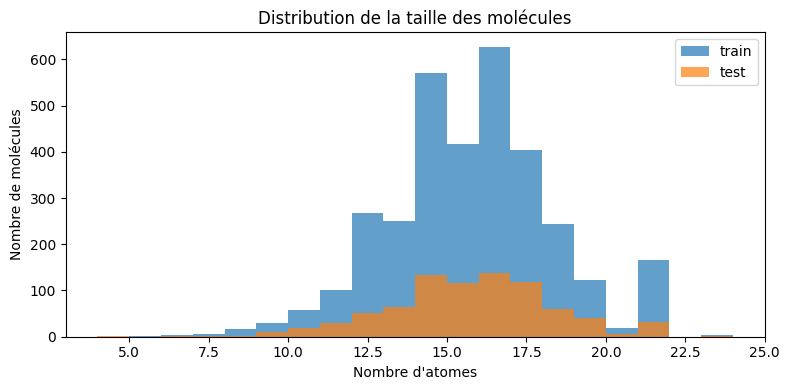

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(train_n_atoms, bins=range(train_n_atoms.min(), MAX_ATOMS + 2), alpha=0.7, label="train")
plt.hist(test_n_atoms, bins=range(test_n_atoms.min(), MAX_ATOMS + 2), alpha=0.7, label="test")
plt.xlabel("Nombre d'atomes")
plt.ylabel("Nombre de molécules")
plt.title("Distribution de la taille des molécules")
plt.legend()
save_current_figure("distribution_taille_molecules.png")
plt.show()


,element,train_count,test_count,train_pct,test_pct
0,C,15294,3778,0.303404,0.299960
1,Cl,1,2,0.000020,0.000159
2,H,30745,7707,0.609923,0.611909
3,N,2332,607,0.046262,0.048194
4,O,2018,500,0.040033,0.039698
5,S,18,1,0.000357,0.000079


Éléments détectés: ['C', 'Cl', 'H', 'N', 'O', 'S']
Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/composition_atomique_train_test.png


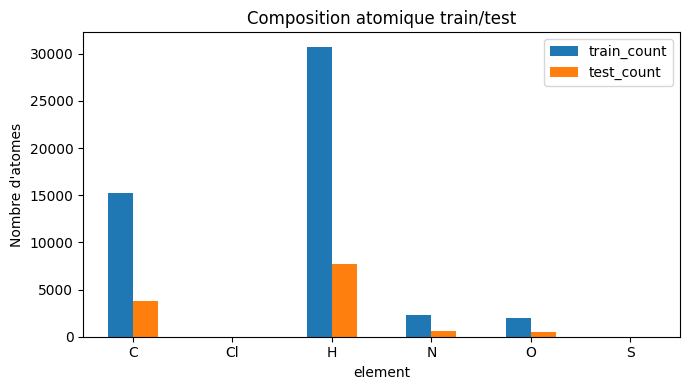

In [8]:
train_element_counts = Counter()
test_element_counts = Counter()

for mol in all_train_molecules:
    train_element_counts.update(mol["symbols"])
for mol in all_test_molecules:
    test_element_counts.update(mol["symbols"])

element_df = pd.DataFrame({
    "element": sorted(set(train_element_counts) | set(test_element_counts)),
})
element_df["train_count"] = element_df["element"].map(train_element_counts).fillna(0).astype(int)
element_df["test_count"] = element_df["element"].map(test_element_counts).fillna(0).astype(int)
element_df["train_pct"] = element_df["train_count"] / element_df["train_count"].sum()
element_df["test_pct"] = element_df["test_count"] / element_df["test_count"].sum()

display(element_df)
ELEMENTS = element_df["element"].tolist()
print("Éléments détectés:", ELEMENTS)

ax = element_df.set_index("element")[["train_count", "test_count"]].plot(kind="bar", figsize=(7, 4))
ax.set_ylabel("Nombre d'atomes")
ax.set_title("Composition atomique train/test")
plt.xticks(rotation=0)
save_current_figure("composition_atomique_train_test.png")
plt.show()


### 4.1 Dataset tabulaire pour l'analyse

On construit une table de synthèse par molécule : nombre d'atomes, formule brute approximative, composition et énergie quand elle est connue. Cette table sert aux visualisations de preprocessing et à l'analyse d'erreurs plus loin dans le notebook.


In [9]:
def molecular_formula(symbols: list[str]) -> str:
    counts = Counter(symbols)
    chunks = []
    for element in sorted(counts):
        count = counts[element]
        chunks.append(element if count == 1 else f"{element}{count}")
    return "".join(chunks)


def molecule_summary(molecule: dict, split: str) -> dict:
    row = {
        "id": molecule["id"],
        "split": split,
        "n_atoms": molecule["n_atoms"],
        "formula": molecular_formula(molecule["symbols"]),
        "sum_atomic_numbers": int(np.sum(molecule["atomic_numbers"])),
    }
    counts = Counter(molecule["symbols"])
    for element in ELEMENTS:
        row[f"n_{element}"] = counts.get(element, 0)
    return row

train_summary_df = pd.DataFrame([molecule_summary(mol, "train") for mol in all_train_molecules])
test_summary_df = pd.DataFrame([molecule_summary(mol, "test") for mol in all_test_molecules])
train_summary_df = train_summary_df.merge(energy_df, on="id", how="left")
all_summary_df = pd.concat([train_summary_df, test_summary_df], ignore_index=True, sort=False)

display(train_summary_df.head())
display(train_summary_df[["n_atoms", "sum_atomic_numbers", "energy"]].describe())


,id,split,n_atoms,formula,sum_atomic_numbers,n_C,n_Cl,n_H,n_N,n_O,n_S,energy
0,1,train,14,C5H8O,46,5,0,8,0,1,0,-68.402811
1,2,train,17,C4H11NO,50,4,0,11,1,1,0,-74.500691
2,3,train,19,C5H13N,50,5,0,13,1,0,0,-82.496414
3,4,train,16,C4H11N,42,4,0,11,1,0,0,-68.552768
4,5,train,16,C4H10N2,48,4,0,10,2,0,0,-69.688330


,n_atoms,sum_atomic_numbers,energy
count,3306.000000,3306.000000,3306.000000
mean,15.247429,46.969752,-70.578505
std,2.613916,4.192890,10.317695
min,5.000000,10.000000,-103.413076
25%,14.000000,46.000000,-75.750647
50%,15.000000,48.000000,-69.422278
75%,17.000000,48.000000,-63.777722
max,23.000000,60.000000,-19.313757


Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/energie_et_taille_dataset.png


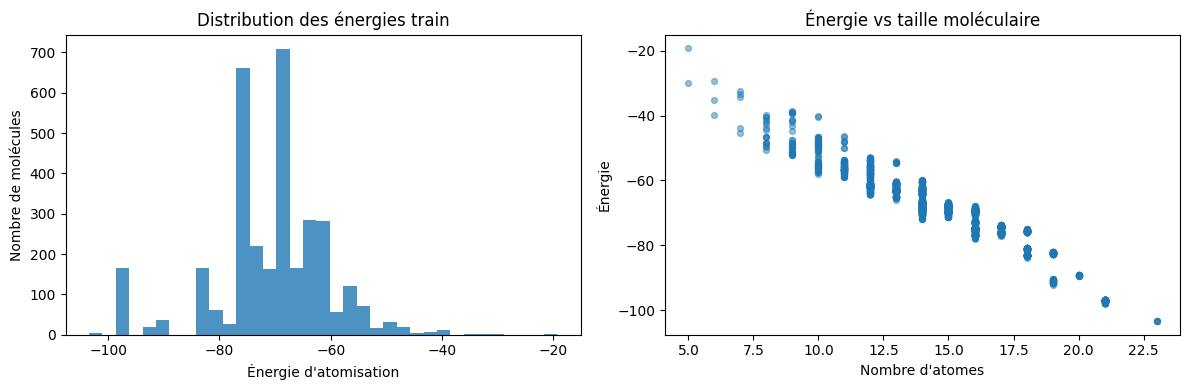

Corrélation énergie / nombre d'atomes: -0.9586160783552037
Corrélation énergie / somme Z: -0.8265298132083763


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_summary_df["energy"], bins=35, color="tab:blue", alpha=0.8)
axes[0].set_xlabel("Énergie d'atomisation")
axes[0].set_ylabel("Nombre de molécules")
axes[0].set_title("Distribution des énergies train")

axes[1].scatter(train_summary_df["n_atoms"], train_summary_df["energy"], alpha=0.45, s=18)
axes[1].set_xlabel("Nombre d'atomes")
axes[1].set_ylabel("Énergie")
axes[1].set_title("Énergie vs taille moléculaire")

save_current_figure("energie_et_taille_dataset.png")
plt.show()

print("Corrélation énergie / nombre d'atomes:", train_summary_df["energy"].corr(train_summary_df["n_atoms"]))
print("Corrélation énergie / somme Z:", train_summary_df["energy"].corr(train_summary_df["sum_atomic_numbers"]))


### 4.2 Visualisation 3D d'une molécule

On garde trois vues complémentaires, chacune avec un rôle différent :

1. **Vue cartésienne sans liaison** : points 3D + labels atomiques + axes. C'est la vue la plus proche des coordonnées brutes utilisées dans les fichiers `.xyz`.
2. **Vue cartésienne avec liaisons estimées par nous** : les liaisons sont ajoutées avec une règle simple basée sur les rayons covalents et une tolérance. C'est utile pédagogiquement, mais cette tolérance reste un choix heuristique.
3. **Vue `py3Dmol`** : représentation moléculaire standard de type ball-and-stick. `py3Dmol` infère l'affichage des liaisons à partir du fichier XYZ avec les règles de 3Dmol.js. C'est plus propre pour visualiser une molécule, mais cela reste une détection géométrique de visualisation, pas un calcul quantique rigoureux des liaisons.


In [11]:
ATOM_COLORS = {
    "H": "#f2f2f2",
    "C": "#202020",
    "N": "#1f77b4",
    "O": "#d62728",
    "F": "#2ca02c",
    "S": "#bcbd22",
    "Cl": "#17becf",
}

ATOM_DISPLAY_SIZES = {
    "H": 5,
    "C": 9,
    "N": 8,
    "O": 8,
    "F": 8,
    "S": 10,
    "Cl": 10,
}

COVALENT_RADII_FOR_VIZ = {
    "H": 0.31,
    "C": 0.76,
    "N": 0.71,
    "O": 0.66,
    "F": 0.57,
    "S": 1.05,
    "Cl": 1.02,
}


def molecule_to_dataframe(molecule: dict) -> pd.DataFrame:
    positions = molecule["positions"]
    return pd.DataFrame({
        "atom": molecule["symbols"],
        "x": positions[:, 0],
        "y": positions[:, 1],
        "z": positions[:, 2],
    })


def molecule_to_xyz_string(molecule: dict, comment: str = "") -> str:
    lines = [str(molecule["n_atoms"]), comment]
    for symbol, position in zip(molecule["symbols"], molecule["positions"]):
        lines.append(f"{symbol} {position[0]:.8f} {position[1]:.8f} {position[2]:.8f}")
    return "\n".join(lines)


def infer_bonds_from_covalent_radii(molecule: dict, tolerance: float = 1.25) -> list[tuple[int, int, float]]:
    """Liaisons estimées par notre règle géométrique : d_ij <= tolerance * (r_i + r_j)."""
    symbols = molecule["symbols"]
    positions = molecule["positions"]
    bonds = []
    for i in range(molecule["n_atoms"]):
        for j in range(i + 1, molecule["n_atoms"]):
            distance = float(np.linalg.norm(positions[i] - positions[j]))
            radius_sum = COVALENT_RADII_FOR_VIZ.get(symbols[i], 0.75) + COVALENT_RADII_FOR_VIZ.get(symbols[j], 0.75)
            if distance <= tolerance * radius_sum:
                bonds.append((i, j, distance))
    return bonds


def infer_bonds_with_ase(molecule: dict) -> tuple[list[tuple[int, int, float]], str]:
    """Option plus standard via ASE, si la bibliothèque est installée."""
    if ASE_AVAILABLE:
        atoms = Atoms(symbols=molecule["symbols"], positions=molecule["positions"])
        cutoffs = natural_cutoffs(atoms, mult=1.15)
        neighbor_list = NeighborList(cutoffs, self_interaction=False, bothways=False)
        neighbor_list.update(atoms)
        bonds = []
        for i in range(len(atoms)):
            indices, offsets = neighbor_list.get_neighbors(i)
            for j, offset in zip(indices, offsets):
                shifted_position = atoms.positions[j] + np.dot(offset, atoms.cell)
                distance = float(np.linalg.norm(atoms.positions[i] - shifted_position))
                bonds.append((i, int(j), distance))
        return bonds, "ASE neighborlist"

    return infer_bonds_from_covalent_radii(molecule), "fallback rayons covalents"


def plot_molecule_cartesian(molecule: dict, title: str | None = None):
    df = molecule_to_dataframe(molecule)
    title = title or f"Vue cartésienne 3D sans liaisons — id_{molecule['id']}"

    if PLOTLY_AVAILABLE:
        fig = go.Figure()
        fig.add_trace(go.Scatter3d(
            x=df["x"], y=df["y"], z=df["z"],
            mode="markers+text",
            text=df["atom"],
            textposition="top center",
            marker=dict(
                size=[ATOM_DISPLAY_SIZES.get(atom, 8) for atom in df["atom"]],
                color=[ATOM_COLORS.get(atom, "gray") for atom in df["atom"]],
                line=dict(width=1, color="black"),
            ),
        ))
        fig.update_layout(
            title=title,
            scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
            width=750,
            height=600,
        )
        fig.show()
        return fig

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(df["x"], df["y"], df["z"], s=80)
    for _, row in df.iterrows():
        ax.text(row["x"], row["y"], row["z"], row["atom"])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)
    plt.show()
    return fig


def plot_molecule_with_manual_bonds(molecule: dict, title: str | None = None, tolerance: float = 1.25):
    df = molecule_to_dataframe(molecule)
    bonds = infer_bonds_from_covalent_radii(molecule, tolerance=tolerance)
    title = title or f"Vue cartésienne avec liaisons estimées — id_{molecule['id']}"

    if PLOTLY_AVAILABLE:
        fig = go.Figure()
        for i, j, distance in bonds:
            fig.add_trace(go.Scatter3d(
                x=[df.loc[i, "x"], df.loc[j, "x"]],
                y=[df.loc[i, "y"], df.loc[j, "y"]],
                z=[df.loc[i, "z"], df.loc[j, "z"]],
                mode="lines",
                line=dict(color="gray", width=7),
                hovertext=f"liaison estimée {df.loc[i, 'atom']}-{df.loc[j, 'atom']} | d={distance:.2f} Å",
                showlegend=False,
            ))
        fig.add_trace(go.Scatter3d(
            x=df["x"], y=df["y"], z=df["z"],
            mode="markers+text",
            text=df["atom"],
            textposition="top center",
            marker=dict(
                size=[ATOM_DISPLAY_SIZES.get(atom, 8) + 3 for atom in df["atom"]],
                color=[ATOM_COLORS.get(atom, "gray") for atom in df["atom"]],
                line=dict(width=1, color="black"),
            ),
            showlegend=False,
        ))
        fig.update_layout(
            title=title,
            scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
            width=750,
            height=600,
        )
        fig.show()
        return fig

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i, j, _ in bonds:
        ax.plot([df.loc[i, "x"], df.loc[j, "x"]], [df.loc[i, "y"], df.loc[j, "y"]], [df.loc[i, "z"], df.loc[j, "z"]], color="gray")
    ax.scatter(df["x"], df["y"], df["z"], s=80)
    for _, row in df.iterrows():
        ax.text(row["x"], row["y"], row["z"], row["atom"])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)
    plt.show()
    return fig


def show_molecule_py3dmol(molecule: dict, title: str | None = None):
    """Affichage ball-and-stick standard avec py3Dmol / 3Dmol.js."""
    if not PY3DMOL_AVAILABLE:
        print("py3Dmol n'est pas installé dans cet environnement.")
        print("Dans le notebook, installe-le avec : %pip install py3Dmol")
        return None

    xyz_text = molecule_to_xyz_string(molecule, comment=title or f"id_{molecule['id']}")
    view = py3Dmol.view(width=750, height=550)
    view.addModel(xyz_text, "xyz")
    view.setStyle({"stick": {"radius": 0.16}, "sphere": {"scale": 0.28}})
    view.setBackgroundColor("white")
    view.zoomTo()
    return view.show()


In [12]:
# Molécule représentative : proche de la taille médiane du train.
median_n_atoms = int(train_summary_df["n_atoms"].median())
representative_id = int(
    train_summary_df.assign(distance_to_median=lambda df: (df["n_atoms"] - median_n_atoms).abs())
    .sort_values(["distance_to_median", "id"])
    .iloc[0]["id"]
)
representative_molecule = train_molecules_by_id[representative_id]
representative_energy = float(energy_df.loc[energy_df["id"] == representative_id, "energy"].iloc[0])
manual_bonds = infer_bonds_from_covalent_radii(representative_molecule, tolerance=1.25)
ase_bonds, ase_method = infer_bonds_with_ase(representative_molecule)

print("Molécule visualisée:", f"id_{representative_id}")
print("Formule:", molecular_formula(representative_molecule["symbols"]))
print("Nombre d'atomes:", representative_molecule["n_atoms"])
print("Énergie:", representative_energy)
print("Liaisons selon notre règle rayons covalents:", len(manual_bonds))
print("Méthode ASE disponible pour comparaison:", ase_method, "| nombre de liaisons:", len(ase_bonds))


Molécule visualisée: id_9
Formule: C4H9NO
Nombre d'atomes: 15
Énergie: -68.5092725570039
Liaisons selon notre règle rayons covalents: 14
Méthode ASE disponible pour comparaison: ASE neighborlist | nombre de liaisons: 14


In [13]:
# Figure 1 : vue cartésienne brute, sans liaison.
plot_molecule_cartesian(
    representative_molecule,
    title=f"Figure 1 — coordonnées cartésiennes sans liaisons | id_{representative_id} | E={representative_energy:.3f}",
)


In [14]:
# Figure 2 : vue cartésienne avec liaisons estimées par notre règle de rayons covalents.
plot_molecule_with_manual_bonds(
    representative_molecule,
    title=f"Figure 2 — liaisons estimées par rayons covalents | id_{representative_id} | E={representative_energy:.3f}",
    tolerance=1.25,
)


In [15]:
# Figure 3 : vue scientifique standard avec py3Dmol / 3Dmol.js.
# Si py3Dmol n'est pas installé, cette cellule explique comment l'ajouter.
show_molecule_py3dmol(
    representative_molecule,
    title=f"Figure 3 — py3Dmol ball-and-stick | id_{representative_id} | E={representative_energy:.3f}",
)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 4.3 Lecture preprocessing pour le rapport

Les visualisations montrent que le dataset contient des molécules de tailles variables, avec une composition dominée par quelques éléments organiques. Cette variabilité justifie une représentation de taille fixe : la matrice de Coulomb est paddée jusqu'au nombre maximal d'atomes observé, puis vectorisée. Les vues 3D rappellent aussi pourquoi un modèle naïf sur les coordonnées brutes serait fragile : les mêmes molécules peuvent être translatées ou tournées sans changer leur énergie.


## 5. Preprocessing moléculaire et représentation invariante

Cette section transforme une molécule de taille variable en un vecteur numérique fixe, tout en respectant les symétries physiques importantes : translation, rotation et permutation des atomes.

Le choix principal est la matrice de Coulomb triée. L'aspect plus original de notre baseline est de la compléter avec des descripteurs simples mais interprétables : composition, statistiques de distances, estimation du nombre de liaisons, rayons covalents et électronégativités. Ces ajouts gardent les invariances car ils dépendent de comptages, de distances ou de statistiques symétriques.


### 5.1 Matrice de Coulomb

Pour une molécule de $N$ atomes, on construit une matrice $N \times N$ :

$$
M_{ij}=\begin{cases}
\frac{1}{2}Z_i^{2.4}, & i=j,\\
\frac{Z_iZ_j}{\lVert R_i-R_j\rVert}, & i\neq j.
\end{cases}
$$

Elle utilise :

- les types d'atomes via les numéros atomiques $Z_i$ ;
- la géométrie via les distances $\lVert R_i-R_j\rVert$.

**Invariances.** Comme la matrice dépend uniquement des distances interatomiques, elle est exactement invariante par translation et rotation. Elle n'est pas automatiquement invariante à la permutation des lignes du fichier `.xyz`; pour réduire ce problème, on trie les lignes et colonnes par norme décroissante. Cette méthode rend la représentation stable dans la plupart des cas, mais elle peut rester ambiguë si deux lignes ont exactement la même norme.

**Taille fixe.** Les molécules n'ont pas toutes le même nombre d'atomes. On padde donc chaque matrice avec des zéros jusqu'à `MAX_ATOMS`, puis on vectorise le triangle supérieur.


In [16]:
def coulomb_matrix(atomic_numbers: np.ndarray, positions: np.ndarray) -> np.ndarray:
    """Construit la matrice de Coulomb brute d'une molécule."""
    atomic_numbers = np.asarray(atomic_numbers, dtype=float)
    positions = np.asarray(positions, dtype=float)
    n_atoms = len(atomic_numbers)

    matrix = np.zeros((n_atoms, n_atoms), dtype=float)

    for i in range(n_atoms):
        for j in range(n_atoms):
            if i == j:
                matrix[i, i] = 0.5 * atomic_numbers[i] ** 2.4
            else:
                distance = np.linalg.norm(positions[i] - positions[j])
                matrix[i, j] = atomic_numbers[i] * atomic_numbers[j] / distance

    return matrix


def sort_coulomb_matrix(matrix: np.ndarray) -> np.ndarray:
    """Trie la matrice par norme décroissante des lignes."""
    row_norms = np.linalg.norm(matrix, axis=1)
    order = np.argsort(-row_norms)
    return matrix[order][:, order]


def pad_square_matrix(matrix: np.ndarray, max_size: int) -> np.ndarray:
    """Padde une matrice carrée avec des zéros jusqu'à max_size x max_size."""
    padded = np.zeros((max_size, max_size), dtype=float)
    n = matrix.shape[0]
    padded[:n, :n] = matrix
    return padded


def vectorize_upper_triangle(matrix: np.ndarray) -> np.ndarray:
    """Vectorise une matrice symétrique via son triangle supérieur."""
    return matrix[np.triu_indices_from(matrix)]


def molecule_to_coulomb_features(molecule: dict, max_atoms: int) -> np.ndarray:
    """Pipeline Coulomb complet : matrice, tri, padding, vectorisation."""
    matrix = coulomb_matrix(molecule["atomic_numbers"], molecule["positions"])
    matrix = sort_coulomb_matrix(matrix)
    matrix = pad_square_matrix(matrix, max_atoms)
    return vectorize_upper_triangle(matrix)


Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/matrice_coulomb_exemple.png


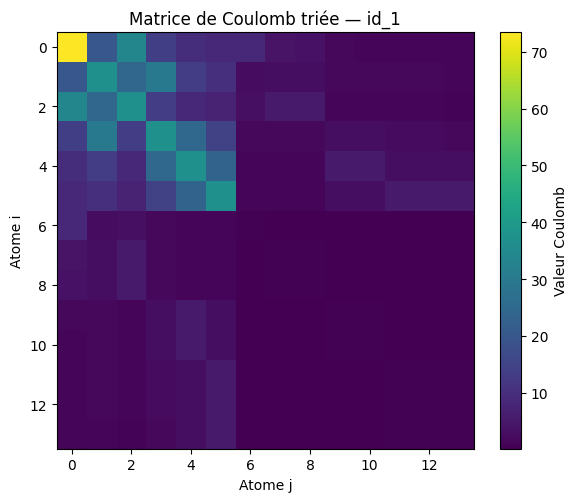

Nombre de features Coulomb: 276


In [17]:
example_matrix = coulomb_matrix(example["atomic_numbers"], example["positions"])
example_sorted_matrix = sort_coulomb_matrix(example_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(example_sorted_matrix)
plt.colorbar(label="Valeur Coulomb")
plt.title(f"Matrice de Coulomb triée — id_{example['id']}")
plt.xlabel("Atome j")
plt.ylabel("Atome i")
save_current_figure("matrice_coulomb_exemple.png")
plt.show()

example_coulomb_features = molecule_to_coulomb_features(example, MAX_ATOMS)
print("Nombre de features Coulomb:", example_coulomb_features.shape[0])


### 5.2 Tests d'invariance

On vérifie empiriquement que la représentation Coulomb triée est stable si on translate, tourne ou permute les atomes d'une molécule exemple. Ce test est important pour le rapport : il relie directement le preprocessing aux contraintes de l'énoncé.


In [18]:
def rotate_positions_z(positions: np.ndarray, theta: float) -> np.ndarray:
    """Rotation simple autour de l'axe z."""
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), 0.0],
        [np.sin(theta),  np.cos(theta), 0.0],
        [0.0,            0.0,           1.0],
    ])
    return positions @ rotation_matrix.T

features_original = molecule_to_coulomb_features(example, MAX_ATOMS)

translated = example.copy()
translated["positions"] = example["positions"] + np.array([10.0, -3.0, 7.0])

rotated = example.copy()
rotated["positions"] = rotate_positions_z(example["positions"], theta=np.pi / 3)

rng = np.random.default_rng(RANDOM_STATE)
permutation = rng.permutation(example["n_atoms"])
permuted = example.copy()
permuted["positions"] = example["positions"][permutation]
permuted["atomic_numbers"] = example["atomic_numbers"][permutation]
permuted["symbols"] = [example["symbols"][i] for i in permutation]

print("Invariance translation:", np.allclose(features_original, molecule_to_coulomb_features(translated, MAX_ATOMS)))
print("Invariance rotation   :", np.allclose(features_original, molecule_to_coulomb_features(rotated, MAX_ATOMS)))
print("Invariance permutation:", np.allclose(features_original, molecule_to_coulomb_features(permuted, MAX_ATOMS)))


Invariance translation: True
Invariance rotation   : True
Invariance permutation: True


### 5.3 Description du modèle pour le rapport

Notre modèle n'apprend pas directement sur les coordonnées cartésiennes. Il apprend sur des représentations construites pour respecter les symétries physiques.

| Composant | Rôle | Invariances |
|---|---|---|
| Matrice de Coulomb | Encode types atomiques et distances | Translation, rotation ; permutation après tri sauf cas d'égalité parfaite des normes |
| Padding + triangle supérieur | Transforme une molécule variable en vecteur fixe | Ne modifie pas les invariances de la matrice triée |
| Composition atomique | Donne le nombre d'atomes de chaque type | Invariant à translation, rotation, permutation |
| Statistiques de distances | Résume la géométrie globale | Invariant à translation, rotation, permutation |
| Rayons / liaisons approximatives | Ajoute une lecture chimique simple | Invariant car basé sur distances et comptages |
| Extra Trees | Régression non linéaire robuste sur features tabulaires | Les invariances viennent des features, pas du modèle d'arbres |

La nouveauté de cette approche, à l'échelle du projet, est donc une baseline Coulomb enrichie avec des informations chimiques simples et interprétables. Ce n'est pas un modèle état de l'art comme DimeNet++ ou SchNet, mais c'est un pipeline défendable, reproductible et facile à analyser.


## 6. Enrichissement des données

La matrice de Coulomb contient déjà beaucoup d'information.  
On ajoute toutefois des features globales pour aider les modèles classiques, notamment les modèles d'arbres.

On distingue trois familles :

1. **Composition** : nombre d'atomes, nombre de H/C/N/O..., somme des numéros atomiques.
2. **Géométrie globale** : statistiques sur les distances interatomiques.
3. **Rayons covalents / liaisons approximatives** : comparaison des distances avec la taille typique des atomes.


In [19]:
# Rayons covalents approximatifs en Angström.
# Ils servent uniquement à fabriquer des features simples et physiquement motivées.
COVALENT_RADII = {
    "H": 0.31,
    "C": 0.76,
    "N": 0.71,
    "O": 0.66,
    "F": 0.57,
    "S": 1.05,
    "Cl": 1.02,
}

# Électronégativités de Pauling approximatives, optionnelles.
# Même idée : features simples, pas un calcul quantique exact.
ELECTRONEGATIVITY = {
    "H": 2.20,
    "C": 2.55,
    "N": 3.04,
    "O": 3.44,
    "F": 3.98,
    "S": 2.58,
    "Cl": 3.16,
}


In [20]:
def pairwise_distances(positions: np.ndarray) -> np.ndarray:
    """Retourne les distances interatomiques du triangle supérieur, sans la diagonale."""
    n_atoms = len(positions)
    distances = []
    for i in range(n_atoms):
        for j in range(i + 1, n_atoms):
            distances.append(np.linalg.norm(positions[i] - positions[j]))
    return np.asarray(distances, dtype=float)


def safe_stats(values: np.ndarray) -> np.ndarray:
    """Statistiques robustes pour un vecteur éventuellement vide."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.zeros(5, dtype=float)
    return np.array([
        np.min(values),
        np.mean(values),
        np.std(values),
        np.median(values),
        np.max(values),
    ], dtype=float)


In [21]:
def composition_features(molecule: dict, elements: list[str]) -> np.ndarray:
    """Features globales de composition atomique."""
    symbols = molecule["symbols"]
    atomic_numbers = molecule["atomic_numbers"]
    counts = Counter(symbols)

    element_counts = [counts.get(element, 0) for element in elements]

    return np.array([
        molecule["n_atoms"],
        np.sum(atomic_numbers),
        np.mean(atomic_numbers),
        np.std(atomic_numbers),
        *element_counts,
    ], dtype=float)


def geometry_features(molecule: dict) -> np.ndarray:
    """Features basées uniquement sur les distances interatomiques."""
    distances = pairwise_distances(molecule["positions"])
    return safe_stats(distances)


def radius_and_bond_features(molecule: dict, tolerance: float = 1.25) -> np.ndarray:
    """
    Features utilisant les rayons covalents.

    Deux atomes sont considérés comme potentiellement liés si :
    distance < tolerance * (rayon_i + rayon_j)
    """
    symbols = molecule["symbols"]
    positions = molecule["positions"]
    n_atoms = molecule["n_atoms"]

    radii = np.array([COVALENT_RADII.get(symbol, 0.75) for symbol in symbols], dtype=float)
    electroneg = np.array([ELECTRONEGATIVITY.get(symbol, 2.5) for symbol in symbols], dtype=float)

    normalized_distances = []
    electroneg_diffs = []
    n_bonds = 0

    for i in range(n_atoms):
        for j in range(i + 1, n_atoms):
            distance = np.linalg.norm(positions[i] - positions[j])
            radius_sum = radii[i] + radii[j]
            normalized_distance = distance / radius_sum
            normalized_distances.append(normalized_distance)
            electroneg_diffs.append(abs(electroneg[i] - electroneg[j]))

            if normalized_distance < tolerance:
                n_bonds += 1

    normalized_distances = np.asarray(normalized_distances, dtype=float)
    electroneg_diffs = np.asarray(electroneg_diffs, dtype=float)

    return np.concatenate([
        np.array([
            np.sum(radii),
            np.mean(radii),
            np.std(radii),
            np.sum(electroneg),
            np.mean(electroneg),
            np.std(electroneg),
            n_bonds,
            n_bonds / max(n_atoms, 1),
        ], dtype=float),
        safe_stats(normalized_distances),
        safe_stats(electroneg_diffs),
    ])


def molecule_to_enriched_features(molecule: dict, max_atoms: int, elements: list[str]) -> np.ndarray:
    """Features complètes : Coulomb + composition + géométrie + rayons/liaisons."""
    return np.concatenate([
        molecule_to_coulomb_features(molecule, max_atoms),
        composition_features(molecule, elements),
        geometry_features(molecule),
        radius_and_bond_features(molecule),
    ])


### Remarque physique

Ajouter simplement “la taille de l'atome” est souvent redondant avec le type d'atome, car un carbone a toujours le même rayon tabulé dans notre représentation.

En revanche, utiliser les rayons pour comparer une distance réelle à une distance chimique typique est plus intéressant : cela donne une approximation de la proximité ou des liaisons possibles.


## 7. Construction des matrices `X` et du vecteur `y`

On construit deux versions des features :

- `X_train_coulomb` : matrice de Coulomb uniquement ;
- `X_train_enriched` : matrice de Coulomb + features ajoutées.

Cela permet de vérifier si l'enrichissement améliore réellement la MAE.


In [22]:
y_train = energy_df["energy"].values
train_ids = energy_df["id"].tolist()

X_train_coulomb = np.array([
    molecule_to_coulomb_features(train_molecules_by_id[mol_id], MAX_ATOMS)
    for mol_id in train_ids
])

X_test_coulomb = np.array([
    molecule_to_coulomb_features(test_molecules_by_id[mol_id], MAX_ATOMS)
    for mol_id in test_ids
])

X_train_enriched = np.array([
    molecule_to_enriched_features(train_molecules_by_id[mol_id], MAX_ATOMS, ELEMENTS)
    for mol_id in train_ids
])

X_test_enriched = np.array([
    molecule_to_enriched_features(test_molecules_by_id[mol_id], MAX_ATOMS, ELEMENTS)
    for mol_id in test_ids
])

print("X_train_coulomb :", X_train_coulomb.shape)
print("X_test_coulomb  :", X_test_coulomb.shape)
print("X_train_enriched:", X_train_enriched.shape)
print("X_test_enriched :", X_test_enriched.shape)
print("y_train         :", y_train.shape)


X_train_coulomb : (3306, 276)
X_test_coulomb  : (826, 276)
X_train_enriched: (3306, 309)
X_test_enriched : (826, 309)
y_train         : (3306,)


In [23]:
assert X_train_coulomb.shape[0] == len(y_train)
assert X_train_enriched.shape[0] == len(y_train)
assert X_train_coulomb.shape[1] == X_test_coulomb.shape[1]
assert X_train_enriched.shape[1] == X_test_enriched.shape[1]
assert not np.isnan(X_train_coulomb).any()
assert not np.isnan(X_train_enriched).any()
assert not np.isnan(y_train).any()


## 8. Validation croisée

On évalue les modèles avec une **MAE en validation croisée** à 5 folds, métrique identique à celle du challenge.

Pour chaque modèle, on garde aussi la MAE train. L'écart train/validation permet de discuter le surapprentissage, ce qui remplace ici une courbe d'entraînement par epoch puisque les modèles testés ne sont pas des réseaux entraînés itérativement.


In [24]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def evaluate_model(model, X: np.ndarray, y: np.ndarray, cv) -> dict:
    """Évalue un modèle en CV avec la MAE."""
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
        n_jobs=-1,
    )
    train_mae = -scores["train_score"]
    val_mae = -scores["test_score"]

    return {
        "train_mae_mean": train_mae.mean(),
        "train_mae_std": train_mae.std(),
        "val_mae_mean": val_mae.mean(),
        "val_mae_std": val_mae.std(),
    }


## 9. Comparaison de modèles

On compare :

1. une baseline constante ;
2. Ridge ;
3. Kernel Ridge RBF ;
4. Extra Trees sur features Coulomb ;
5. Extra Trees sur features enrichies.

Pour aller vite pendant le développement, tu peux diminuer `n_estimators` ou commenter `KernelRidge`, qui peut être plus lent.


In [25]:
models_to_evaluate = {
    "Dummy median | Coulomb": (
        DummyRegressor(strategy="median"),
        X_train_coulomb,
    ),
    "Ridge | Coulomb": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
        X_train_coulomb,
    ),
    "Kernel Ridge RBF | Coulomb": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KernelRidge(alpha=1.0, kernel="rbf", gamma=0.01)),
        ]),
        X_train_coulomb,
    ),
    "Extra Trees | Coulomb": (
        ExtraTreesRegressor(
            n_estimators=300,
            max_features=1.0,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_train_coulomb,
    ),
    "Extra Trees | Enriched": (
        ExtraTreesRegressor(
            n_estimators=300,
            max_features=1.0,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_train_enriched,
    ),
}

results = []
for name, (model, X) in models_to_evaluate.items():
    print("Évaluation:", name)
    result = evaluate_model(model, X, y_train, cv)
    results.append({"model": name, **result})

results_df = pd.DataFrame(results).sort_values("val_mae_mean")
display(results_df)


Évaluation: Dummy median | Coulomb
Évaluation: Ridge | Coulomb
Évaluation: Kernel Ridge RBF | Coulomb
Évaluation: Extra Trees | Coulomb
Évaluation: Extra Trees | Enriched


,model,train_mae_mean,train_mae_std,val_mae_mean,val_mae_std
4,Extra Trees | Enriched,1.177732e-11,1.179908e-11,0.129830,0.010800
3,Extra Trees | Coulomb,1.546689e-11,7.392085e-12,0.164022,0.009654
1,Ridge | Coulomb,1.108827e+00,5.441168e-03,1.211570,0.007623
2,Kernel Ridge RBF | Coulomb,4.389942e+00,1.874828e-02,7.343704,0.767498
0,Dummy median | Coulomb,7.485434e+00,4.505855e-02,7.486442,0.180196


Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/comparaison_modeles_train_validation.png


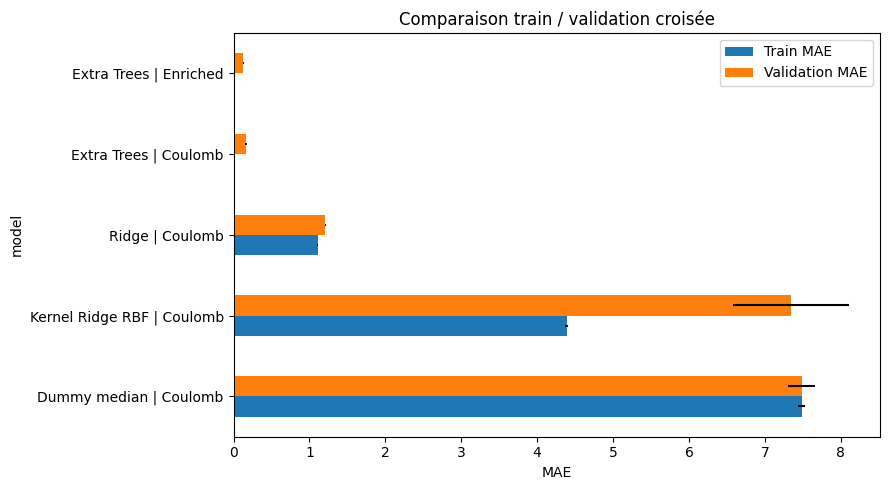

In [26]:
plot_df = results_df.sort_values("val_mae_mean", ascending=False).set_index("model")

ax = plot_df[["train_mae_mean", "val_mae_mean"]].plot(
    kind="barh",
    figsize=(9, 5),
    xerr=plot_df[["train_mae_std", "val_mae_std"]].T.values,
)
ax.set_xlabel("MAE")
ax.set_title("Comparaison train / validation croisée")
ax.legend(["Train MAE", "Validation MAE"])
save_current_figure("comparaison_modeles_train_validation.png")
plt.show()


## 10. Recherche simple d'hyperparamètres

On ajuste quelques paramètres de `ExtraTreesRegressor` : nombre d'arbres, proportion de features considérées et taille minimale des feuilles. Le but n'est pas une recherche exhaustive, mais un tuning clair et reproductible qui répond au barème.


In [27]:
parameter_grid = [
    {"n_estimators": 300, "max_features": 1.0, "min_samples_leaf": 1},
    {"n_estimators": 500, "max_features": 1.0, "min_samples_leaf": 1},
    {"n_estimators": 500, "max_features": 0.7, "min_samples_leaf": 1},
    {"n_estimators": 500, "max_features": 1.0, "min_samples_leaf": 2},
]

tuning_results = []
for params in parameter_grid:
    print("Test params:", params)
    model = ExtraTreesRegressor(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    result = evaluate_model(model, X_train_enriched, y_train, cv)
    tuning_results.append({**params, **result})

tuning_df = pd.DataFrame(tuning_results).sort_values("val_mae_mean")
display(tuning_df)


Test params: {'n_estimators': 300, 'max_features': 1.0, 'min_samples_leaf': 1}
Test params: {'n_estimators': 500, 'max_features': 1.0, 'min_samples_leaf': 1}
Test params: {'n_estimators': 500, 'max_features': 0.7, 'min_samples_leaf': 1}
Test params: {'n_estimators': 500, 'max_features': 1.0, 'min_samples_leaf': 2}


,n_estimators,max_features,min_samples_leaf,train_mae_mean,train_mae_std,val_mae_mean,val_mae_std
1,500,1.0,1,1.052308e-11,7.700751e-12,0.129335,0.010759
0,300,1.0,1,1.177731e-11,1.179908e-11,0.129830,0.010800
2,500,0.7,1,1.693758e-11,1.074293e-11,0.132601,0.010004
3,500,1.0,2,2.591347e-02,2.161760e-03,0.138892,0.011396


Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/tuning_extra_trees.png


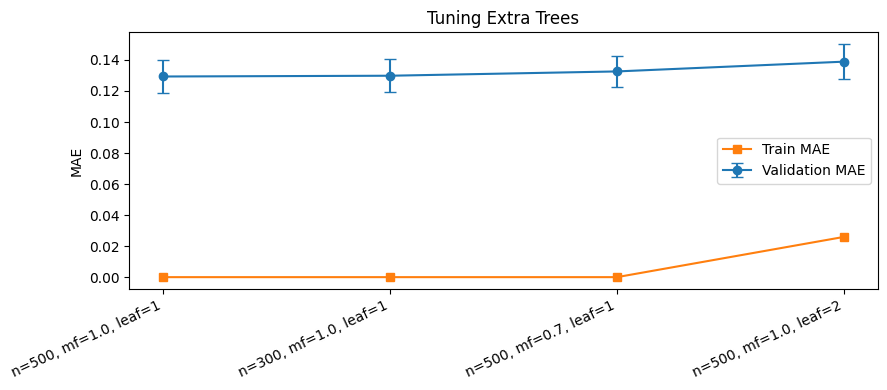

In [28]:
tuning_plot_df = tuning_df.copy()
tuning_plot_df["config"] = [
    f"n={int(row.n_estimators)}, mf={row.max_features}, leaf={int(row.min_samples_leaf)}"
    for row in tuning_plot_df.itertuples()
]

plt.figure(figsize=(9, 4))
plt.errorbar(
    tuning_plot_df["config"],
    tuning_plot_df["val_mae_mean"],
    yerr=tuning_plot_df["val_mae_std"],
    marker="o",
    capsize=4,
    label="Validation MAE",
)
plt.plot(tuning_plot_df["config"], tuning_plot_df["train_mae_mean"], marker="s", label="Train MAE")
plt.ylabel("MAE")
plt.title("Tuning Extra Trees")
plt.xticks(rotation=25, ha="right")
plt.legend()
save_current_figure("tuning_extra_trees.png")
plt.show()


In [29]:
best_params = tuning_df.iloc[0][["n_estimators", "max_features", "min_samples_leaf"]].to_dict()
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

best_params


{'n_estimators': 500, 'max_features': 1.0, 'min_samples_leaf': 1}

## 11. Analyse des erreurs avec prédictions out-of-fold

Les prédictions out-of-fold sont obtenues sur des molécules que le modèle n'a pas vues pendant son entraînement.  
Elles sont donc utiles pour analyser les erreurs sans tricher.


In [30]:
best_model = ExtraTreesRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

oof_predictions = cross_val_predict(
    best_model,
    X_train_enriched,
    y_train,
    cv=cv,
    n_jobs=-1,
)

oof_mae = mean_absolute_error(y_train, oof_predictions)
print("MAE out-of-fold:", oof_mae)


MAE out-of-fold: 0.12933242860546865


Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/oof_predictions.png


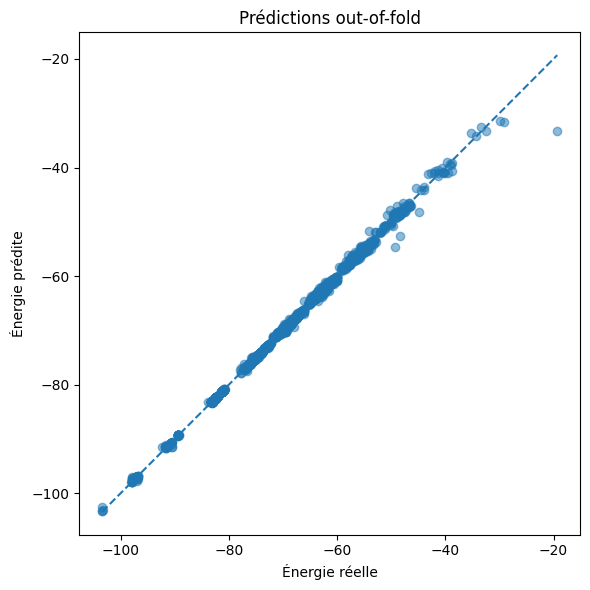

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, oof_predictions, alpha=0.5)
limits = [min(y_train.min(), oof_predictions.min()), max(y_train.max(), oof_predictions.max())]
plt.plot(limits, limits, linestyle="--")
plt.xlabel("Énergie réelle")
plt.ylabel("Énergie prédite")
plt.title("Prédictions out-of-fold")
save_current_figure("oof_predictions.png")
plt.show()


In [32]:
error_df = energy_df.copy()
error_df["prediction"] = oof_predictions
error_df["absolute_error"] = np.abs(error_df["energy"] - error_df["prediction"])
error_df["n_atoms"] = error_df["id"].apply(lambda mol_id: train_molecules_by_id[mol_id]["n_atoms"])

worst_predictions = error_df.sort_values("absolute_error", ascending=False).head(15)
display(worst_predictions)


,id,energy,prediction,absolute_error,n_atoms
2013,2014,-19.313757,-33.268054,13.954297,5
401,402,-49.214565,-54.596347,5.381782,10
820,821,-48.377957,-52.520773,4.142815,9
1625,1626,-44.835717,-48.217151,3.381434,9
1181,1182,-54.101544,-51.688926,2.412618,10
2105,2106,-50.138173,-47.767053,2.371120,9
1250,1251,-29.219011,-31.536786,2.317775,6
2357,2358,-50.739882,-48.698847,2.041035,8
515,516,-43.231962,-41.251699,1.980262,9
935,936,-48.958448,-47.041540,1.916909,10


Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/analyse_erreurs_oof.png


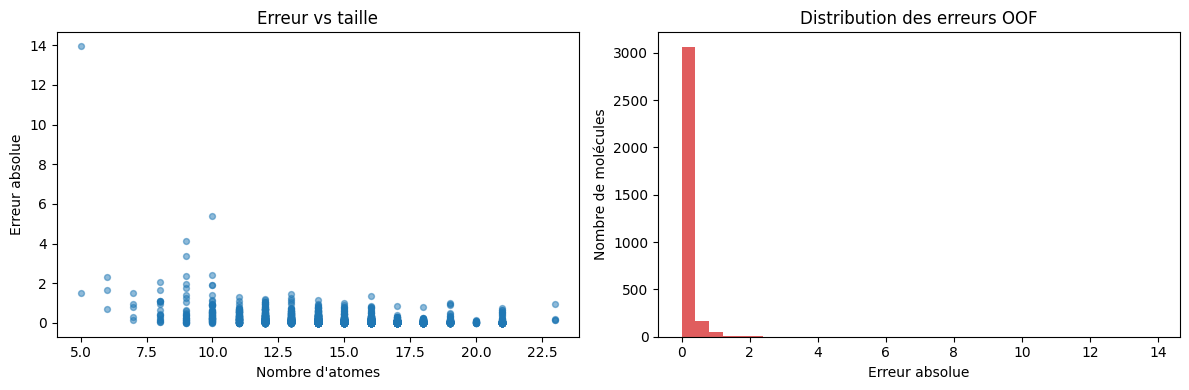

,n_atoms,count,mean,median,max
0,5,2,7.722810,7.722810,13.954297
1,6,3,1.550276,1.639356,2.317775
2,7,5,0.745146,0.782893,1.511561
3,8,17,0.687301,0.423674,2.041035
4,9,29,0.774048,0.342692,4.142815
5,10,58,0.604105,0.398980,5.381782
6,11,102,0.284386,0.201857,1.323200
7,12,268,0.222086,0.129905,1.216602
8,13,251,0.169496,0.093007,1.451458
9,14,570,0.115659,0.060255,1.142059


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(error_df["n_atoms"], error_df["absolute_error"], alpha=0.5, s=18)
axes[0].set_xlabel("Nombre d'atomes")
axes[0].set_ylabel("Erreur absolue")
axes[0].set_title("Erreur vs taille")

axes[1].hist(error_df["absolute_error"], bins=35, color="tab:red", alpha=0.75)
axes[1].set_xlabel("Erreur absolue")
axes[1].set_ylabel("Nombre de molécules")
axes[1].set_title("Distribution des erreurs OOF")

save_current_figure("analyse_erreurs_oof.png")
plt.show()

error_by_size = error_df.groupby("n_atoms")["absolute_error"].agg(["count", "mean", "median", "max"]).reset_index()
display(error_by_size)


### 11.1 Synthèse d'analyse pour le rapport

Les éléments à reporter sont :

- la meilleure MAE en validation croisée, qui sert d'estimation principale de performance ;
- l'écart train/validation, qui indique le niveau de surapprentissage ;
- le gain entre Coulomb seul et Coulomb enrichi, qui mesure l'intérêt des features ajoutées ;
- les molécules avec plus forte erreur OOF, utiles pour discuter les limites du modèle ;
- l'erreur en fonction du nombre d'atomes, pour vérifier si les grandes molécules sont plus difficiles.


In [34]:
best_cv_row = results_df.sort_values("val_mae_mean").iloc[0]
best_tuning_row = tuning_df.sort_values("val_mae_mean").iloc[0]

analysis_summary = {
    "best_model_cv": best_cv_row["model"],
    "best_cv_val_mae_mean": float(best_cv_row["val_mae_mean"]),
    "best_cv_val_mae_std": float(best_cv_row["val_mae_std"]),
    "best_cv_train_mae_mean": float(best_cv_row["train_mae_mean"]),
    "best_tuned_val_mae_mean": float(best_tuning_row["val_mae_mean"]),
    "best_tuned_val_mae_std": float(best_tuning_row["val_mae_std"]),
    "oof_mae": float(oof_mae),
    "best_params": best_params,
}

print(json.dumps(analysis_summary, indent=2, ensure_ascii=False))

with open(OUTPUT_DIR / "analysis_summary.json", "w") as f:
    json.dump(analysis_summary, f, indent=2, ensure_ascii=False)


{
  "best_model_cv": "Extra Trees | Enriched",
  "best_cv_val_mae_mean": 0.12983012618540074,
  "best_cv_val_mae_std": 0.010800387684547006,
  "best_cv_train_mae_mean": 1.1777317183983374e-11,
  "best_tuned_val_mae_mean": 0.129334727970874,
  "best_tuned_val_mae_std": 0.010759329767599995,
  "oof_mae": 0.12933242860546865,
  "best_params": {
    "n_estimators": 500,
    "max_features": 1.0,
    "min_samples_leaf": 1
  }
}


## 12. Entraînement final et soumission

Une fois le modèle choisi avec la validation croisée, on l'entraîne sur toutes les données train connues, puis on prédit les molécules test.


In [35]:
final_model = ExtraTreesRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_model.fit(X_train_enriched, y_train)

test_predictions = final_model.predict(X_test_enriched)
print(test_predictions[:10])
print(test_predictions.shape)


[-75.027609   -62.16268137 -69.00073421 -61.33853313 -52.58954216
 -97.10432985 -90.69554013 -55.95524202 -53.90286116 -82.56291291]
(826,)


,id,energy
0,3307,-75.027609
1,3308,-62.162681
2,3309,-69.000734
3,3310,-61.338533
4,3311,-52.589542


Fichier créé: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/submission_coulomb_enriched.csv
Figure sauvegardée: /Users/victorlin/Desktop/N7 3A/Projet/Model_Coulomb/outputs/figures/distribution_predictions_test.png


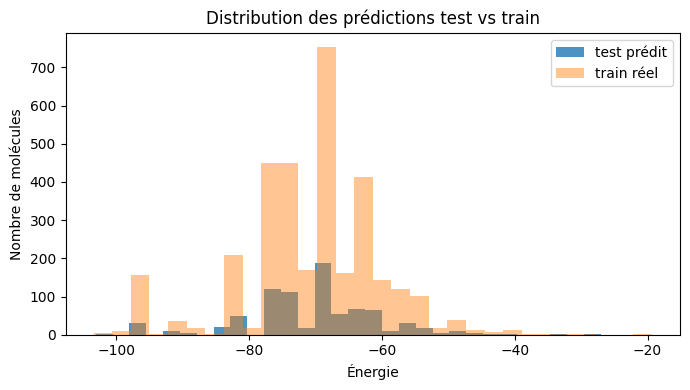

In [36]:
submission_df = pd.DataFrame({
    "id": test_ids,
    "energy": test_predictions,
})

submission_path = OUTPUT_DIR / "submission_coulomb_enriched.csv"
submission_df.to_csv(submission_path, index=False)

display(submission_df.head())
print("Fichier créé:", submission_path)

assert list(submission_df.columns) == ["id", "energy"]
assert len(submission_df) == len(test_ids)
assert not submission_df["energy"].isna().any()

plt.figure(figsize=(7, 4))
plt.hist(submission_df["energy"], bins=30, alpha=0.8, label="test prédit")
plt.hist(energy_df["energy"], bins=30, alpha=0.45, label="train réel")
plt.xlabel("Énergie")
plt.ylabel("Nombre de molécules")
plt.title("Distribution des prédictions test vs train")
plt.legend()
save_current_figure("distribution_predictions_test.png")
plt.show()


## 13. Conclusion, limites et perspectives

### Résumé de la méthode

Nous avons construit une baseline ML classique fondée sur la matrice de Coulomb triée. Cette représentation encode les types d'atomes via les numéros atomiques et la géométrie via les distances interatomiques. Elle respecte exactement les invariances par translation et rotation, et traite la permutation des atomes par un tri des lignes/colonnes selon la norme.

Le modèle final utilise un `ExtraTreesRegressor` entraîné sur des features enrichies : matrice de Coulomb, composition, statistiques de distances, rayons covalents, électronégativité et nombre de liaisons approximatives. Le choix du modèle et des hyperparamètres est fait par MAE en validation croisée, puis le modèle est réentraîné sur tout le train pour produire la soumission Kaggle.

### Points forts

- Pipeline simple, reproductible et rapide à entraîner.
- Représentation physiquement motivée et compatible avec les symétries de l'énoncé.
- Validation croisée et prédictions out-of-fold pour analyser les résultats sans fuite de données.
- Features enrichies interprétables pour discuter les erreurs.

### Limites

- Le tri de la matrice de Coulomb n'est pas une invariance parfaite en cas de lignes de normes égales.
- La matrice de Coulomb décrit surtout des interactions par paires et ne capture pas explicitement les angles ou interactions à plus haut ordre.
- Les liaisons sont approximées à partir de distances et de rayons tabulés ; ce n'est pas une vraie optimisation chimique.
- Les modèles d'arbres n'exploitent pas directement la structure de graphe moléculaire.

### État de l'art et future work

Pour améliorer les performances, on peut comparer cette baseline à des modèles géométriques modernes : SchNet, DimeNet++, PaiNN, GemNet ou des réseaux équivariants E(3). Ces modèles apprennent directement sur les graphes moléculaires et utilisent distances, angles et messages entre atomes. Ils sont mieux adaptés aux surfaces d'énergie moléculaire, mais demandent plus de temps de calcul et une implémentation plus lourde.

Une suite raisonnable serait :

- remplacer le tri Coulomb par des descripteurs plus stables, par exemple Bag of Bonds ou SOAP ;
- ajouter une vraie courbe d'apprentissage en fonction du nombre de molécules train ;
- tester un modèle GNN géométrique sur le même split de validation ;
- faire une analyse chimique des pires erreurs, notamment par formule brute et nombre d'atomes.

### Phrase de conclusion courte

La matrice de Coulomb enrichie fournit une baseline solide : elle respecte les invariances essentielles, donne des features interprétables et permet une évaluation propre par validation croisée. Ses limites viennent surtout de l'absence d'information angulaire explicite et du traitement imparfait des permutations, ce qui motive le passage à des modèles géométriques plus avancés.
